# 장애인콜택시 대기시간 예측 모델링 - Ridge Regression

이 노트북은 VSCode에서 현재 프로젝트 폴더 기준으로 전처리 CSV를 불러와 `접수→승차 대기시간`을 예측하는 Ridge Regression 모델링 노트북이다.

## 목적

- 프로젝트 폴더의 `data/processed`에서 전처리 CSV 불러오기
- 임차택시 바로콜 / 특장차 바로콜 승차완료 데이터 생성
- 예측 대상 `target_min = 접수→승차 대기시간` 생성
- 130분 이후 장시간 대기와 02~06시 새벽 호출을 별도관리 구간으로 분리
- 기존과 동일하게 train / validation / test 분리
- Ridge Regression 기반 모델 학습
- `차량운행` 공급 proxy 추가 전후 성능 비교

## 모델링 기준

전체 데이터는 보존하되, 일반 패턴 모델에서는 아래 조건을 제외한 버전으로 학습한다.

```text
1. 접수→승차 대기시간 130분 초과
2. 접수시간 02~06시
3. 위 두 조건이 겹치는 데이터
```

주의: Ridge는 선형 회귀 계열 모델이므로 범주형 변수는 One-Hot Encoding으로 처리한다.


## 1. 라이브러리 및 로컬 프로젝트 경로 설정

VSCode에서 이 노트북을 실행할 때는 Google Drive 경로를 사용하지 않는다.

현재 프로젝트 구조를 기준으로 아래 CSV를 불러온다.

```text
data/processed/임차택시_대기시간_전처리.csv
data/processed/특장차_대기시간_전처리_접수유형분류.csv
```

노트북 실행 위치가 프로젝트 루트이든 `notebooks_waiting_time` 폴더이든 자동으로 프로젝트 루트를 찾도록 설정한다.

In [1]:
from pathlib import Path
import unicodedata
import platform

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False


In [2]:
# =========================
# 로컬 프로젝트 경로 설정
# =========================

RENTAL_FILENAME = "임차택시_대기시간_전처리.csv"
SPECIAL_FILENAME = "특장차_대기시간_전처리_접수유형분류.csv"


def normalize_text(text):
    return unicodedata.normalize("NFC", str(text))


def find_project_root(start_path=None):
    """
    현재 실행 위치에서 위로 올라가며 data/processed 폴더가 있는 프로젝트 루트를 찾는다.
    """
    start = Path.cwd() if start_path is None else Path(start_path)
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError(
        "data/processed 폴더를 찾을 수 없습니다. "
        "VSCode의 현재 작업 폴더가 calltaxi-DA 프로젝트 안인지 확인하세요."
    )


def find_csv_in_processed(processed_dir, filename):
    """
    1순위: data/processed/{filename}
    2순위: 한글 자모 정규화 차이를 고려해 processed 폴더의 CSV 전체에서 파일명 비교
    """
    direct_path = processed_dir / filename

    if direct_path.exists():
        return direct_path

    target_name = normalize_text(filename)
    matches = [
        path
        for path in processed_dir.rglob("*.csv")
        if normalize_text(path.name) == target_name
    ]

    if len(matches) == 0:
        print("processed 폴더에서 찾은 CSV 파일:")
        for path in sorted(processed_dir.rglob("*.csv")):
            print(" -", path)
        raise FileNotFoundError(
            f"{filename} 파일을 찾을 수 없습니다. "
            f"{processed_dir} 안의 파일명을 확인하세요."
        )

    if len(matches) > 1:
        print(f"{filename} 후보가 여러 개입니다. 첫 번째 파일을 사용합니다.")
        for path in matches:
            print(" -", path)

    return matches[0]


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "processed"

RENTAL_PATH = find_csv_in_processed(DATA_DIR, RENTAL_FILENAME)
SPECIAL_PATH = find_csv_in_processed(DATA_DIR, SPECIAL_FILENAME)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("RENTAL_PATH:", RENTAL_PATH)
print("SPECIAL_PATH:", SPECIAL_PATH)
print("RENTAL exists:", RENTAL_PATH.exists())
print("SPECIAL exists:", SPECIAL_PATH.exists())

PROJECT_ROOT: /Users/blaumonde/calltaxi-DA
DATA_DIR: /Users/blaumonde/calltaxi-DA/data/processed
RENTAL_PATH: /Users/blaumonde/calltaxi-DA/data/processed/임차택시_대기시간_전처리.csv
SPECIAL_PATH: /Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리_접수유형분류.csv
RENTAL exists: True
SPECIAL exists: True


## 2. 데이터 로드

모델링 대상은 기존과 동일하게 바로콜 승차완료 데이터만 사용한다.

- 임차택시: `임차택시_바로콜여부 == True`, `대기시간분석_포함여부 == True`
- 특장차: `특장차_바로콜_후보여부 == True` 또는 `특장차_접수유형_후보_최종 == "바로콜 후보"`

In [3]:
SEOUL_GU = {
    "강남구", "강동구", "강북구", "강서구", "관악구",
    "광진구", "구로구", "금천구", "노원구", "도봉구",
    "동대문구", "동작구", "마포구", "서대문구", "서초구",
    "성동구", "성북구", "송파구", "양천구", "영등포구",
    "용산구", "은평구", "종로구", "중구", "중랑구",
}


def existing_cols(path, wanted_cols):
    header = pd.read_csv(path, nrows=0).columns.tolist()
    return [col for col in wanted_cols if col in header]


def classify_move_type(row):
    origin = row.get("출발구")
    dest = row.get("목적구")

    origin_in_seoul = origin in SEOUL_GU
    dest_in_seoul = dest in SEOUL_GU

    if origin_in_seoul and dest_in_seoul:
        if origin == dest:
            return "구 내 이동"
        return "구 간 이동"

    if origin_in_seoul and not dest_in_seoul:
        return "서울→서울 외"

    if not origin_in_seoul and dest_in_seoul:
        return "서울 외→서울"

    return "서울 외↔서울 외"


def load_modeling_dataset():
    common_cols = [
        "접수일시", "예정일시", "배차일시", "승차일시", "하차일시", "취소일시",
        "출발구", "출발동", "목적구", "목적동",
        "이용목적", "요금", "승차거리", "차량구분", "장애유형",
        "접수_배차_분", "배차_승차_분", "접수_승차_분",
        "접수_취소_분", "배차_취소_분", "접수승차_날짜차이",
    ]

    rental_cols = common_cols + [
        "예약목적여부",
        "임차택시_바로콜여부",
        "임차택시_장시간예외여부",
        "임차택시_예약성예외여부",
        "임차택시_취소분석유형",
        "대기시간분석_포함여부",
        "대기시간분석_제외사유",
    ]

    special_cols = common_cols + [
        "접수시간대", "접수시간대_HH", "접수요일", "평일주말",
        "세부이동유형", "승차거리_km", "승차거리구간",
        "특장차_접수유형", "특장차_접수유형_분류상태", "특장차_접수유형_메모",
        "접수일자", "예정일자", "취소일자", "접수시", "예정시", "예정시간",
        "취소_접수유형_후보", "_원자료_index",
        "특장차_탑승완료_필수일시존재여부",
        "특장차_탑승완료_시간논리정상여부",
        "심야시간사전예약_후보여부",
        "전일접수_후보여부",
        "특장차_바로콜_후보여부",
        "특장차_접수유형_후보_보완",
        "정기접수_목적후보여부",
        "정기접수_가능패턴여부",
        "동일패턴건수_보완",
        "예정_배차_분", "예정_승차_분",
        "특장차_접수유형_후보_최종",
    ]

    rental = pd.read_csv(
        RENTAL_PATH,
        usecols=existing_cols(RENTAL_PATH, rental_cols),
        low_memory=False,
    )

    special = pd.read_csv(
        SPECIAL_PATH,
        usecols=existing_cols(SPECIAL_PATH, special_cols),
        low_memory=False,
    )

    print("임차택시 원본 shape:", rental.shape)
    print("특장차 원본 shape:", special.shape)

    # datetime 변환
    for frame in [rental, special]:
        for col in [
            "접수일시", "예정일시", "배차일시", "승차일시", "하차일시", "취소일시",
            "접수일자", "예정일자", "취소일자",
        ]:
            if col in frame.columns:
                frame[col] = pd.to_datetime(frame[col], errors="coerce")

    # 임차택시 바로콜 승차완료
    rental_model = rental[
        rental["접수일시"].notna()
        & rental["승차일시"].notna()
        & rental["임차택시_바로콜여부"].fillna(False).astype(bool)
        & rental["대기시간분석_포함여부"].fillna(False).astype(bool)
    ].copy()

    rental_model["model_group"] = "임차택시_바로콜"

    # 특장차 바로콜 승차완료
    special_model = special[
        special["접수일시"].notna()
        & special["승차일시"].notna()
        & (
            special["특장차_바로콜_후보여부"].fillna(False).astype(bool)
            | special["특장차_접수유형_후보_최종"].eq("바로콜 후보")
        )
    ].copy()

    special_model["model_group"] = "특장차_바로콜"

    print("임차택시 바로콜 승차완료:", rental_model.shape)
    print("특장차 바로콜 승차완료:", special_model.shape)

    # 컬럼 맞춰서 결합
    all_cols = sorted(set(rental_model.columns) | set(special_model.columns))

    data = pd.concat(
        [
            rental_model.reindex(columns=all_cols),
            special_model.reindex(columns=all_cols),
        ],
        ignore_index=True,
    )

    # numeric 변환
    numeric_cols = [
        "요금", "승차거리", "승차거리_km",
        "접수_배차_분", "배차_승차_분", "접수_승차_분",
        "접수_취소_분", "배차_취소_분", "접수승차_날짜차이",
        "접수시간대_HH", "접수시", "예정시",
        "예정_배차_분", "예정_승차_분", "동일패턴건수_보완",
    ]

    for col in numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    # target 생성
    data = data[
        data["접수일시"].notna()
        & data["승차일시"].notna()
        & data["접수_승차_분"].notna()
        & data["접수_승차_분"].ge(0)
    ].copy()

    data["target_min"] = data["접수_승차_분"]

    # 시간 변수
    data["hour"] = data["접수일시"].dt.hour.astype("int16")
    data["dayofweek"] = data["접수일시"].dt.dayofweek.astype("int16")
    data["month"] = data["접수일시"].dt.month.astype("int16")

    data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype("int8")
    data["is_night"] = data["hour"].between(0, 6, inclusive="both").astype("int8")
    data["is_dawn_02_06"] = data["hour"].between(2, 6, inclusive="both").astype("int8")
    data["is_commute"] = (
        data["hour"].between(7, 9, inclusive="both")
        | data["hour"].between(17, 19, inclusive="both")
    ).astype("int8")

    # 승차거리_km 통일
    if "승차거리_km" not in data.columns:
        data["승차거리_km"] = np.nan

    if "승차거리" in data.columns:
        data["승차거리_km"] = data["승차거리_km"].fillna(
            pd.to_numeric(data["승차거리"], errors="coerce")
        )

    # 세부이동유형 보완
    computed_move_type = data.apply(classify_move_type, axis=1)

    if "세부이동유형" in data.columns:
        data["세부이동유형"] = data["세부이동유형"].fillna(computed_move_type)
        data.loc[data["세부이동유형"].astype(str).eq(""), "세부이동유형"] = computed_move_type
    else:
        data["세부이동유형"] = computed_move_type

    # 문자열 결측 처리
    object_cols = data.select_dtypes(include="object").columns

    for col in object_cols:
        data[col] = data[col].fillna("미상").astype(str)

    data = data.sort_values("접수일시").reset_index(drop=True)

    return data

## 3. 데이터 로드 실행

In [4]:
data = load_modeling_dataset()

print("최종 data shape:", data.shape)
display(data.head())

임차택시 원본 shape: (328875, 28)
특장차 원본 shape: (1393534, 51)
임차택시 바로콜 승차완료: (305729, 29)
특장차 바로콜 승차완료: (1099084, 52)


/var/folders/br/x7f7fw1907z6wpb38fpn1kpm0000gn/T/ipykernel_23241/3787358709.py:189: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = data.select_dtypes(include="object").columns


최종 data shape: (1404813, 67)


,_원자료_index,model_group,대기시간분석_제외사유,대기시간분석_포함여부,동일패턴건수_보완,목적구,목적동,배차_승차_분,배차_취소_분,배차일시,세부이동유형,승차거리,승차거리_km,승차거리구간,승차일시,심야시간사전예약_후보여부,예약목적여부,예정_배차_분,예정_승차_분,예정시,예정시간,예정일시,예정일자,요금,이용목적,임차택시_바로콜여부,임차택시_예약성예외여부,임차택시_장시간예외여부,임차택시_취소분석유형,장애유형,전일접수_후보여부,접수_배차_분,접수_승차_분,접수_취소_분,접수승차_날짜차이,접수시,접수시간대,접수시간대_HH,접수요일,접수일시,접수일자,정기접수_가능패턴여부,정기접수_목적후보여부,차량구분,출발구,출발동,취소_접수유형_후보,취소일시,취소일자,특장차_바로콜_후보여부,특장차_접수유형,특장차_접수유형_메모,특장차_접수유형_분류상태,특장차_접수유형_후보_보완,특장차_접수유형_후보_최종,특장차_탑승완료_시간논리정상여부,특장차_탑승완료_필수일시존재여부,평일주말,하차일시,target_min,hour,dayofweek,month,is_weekend,is_night,is_dawn_02_06,is_commute
0,0.0,특장차_바로콜,미상,미상,0.0,강북구,수유제2동,22.361000,NaN,2025-01-01 00:27:31.307,구 간 이동,17667,17.667,15~25km,2025-01-01 00:49:52.967,False,미상,26.086333,48.447333,0.0,00:01:26,2025-01-01 00:01:26.127,2025-01-01 00:00:00,3400.0,기타,미상,미상,미상,미상,지체,False,26.086333,48.447333,NaN,0.0,0.0,00:00:00,0.0,수,2025-01-01 00:01:26.127,2025-01-01 00:00:00,False,False,특장차,용산구,남영동,취소 아님,NaT,미상,True,NaN,NaN,미분류,바로콜 후보,바로콜 후보,True,True,평일,2025-01-01 01:35:06.747,48.447333,0,2,1,0,1,0,0
1,2.0,특장차_바로콜,미상,미상,0.0,노원구,하계1동,16.608883,NaN,2025-01-01 00:19:41.900,구 내 이동,2910,2.910,0.5~3km,2025-01-01 00:36:18.433,False,미상,15.698333,32.307217,0.0,00:04:00,2025-01-01 00:04:00.000,2025-01-01 00:00:00,1500.0,기타,미상,미상,미상,미상,뇌병,False,16.177833,32.786717,NaN,0.0,0.0,00:00:00,0.0,수,2025-01-01 00:03:31.230,2025-01-01 00:00:00,False,False,특장차,노원구,상계5동,취소 아님,NaT,미상,True,NaN,NaN,미분류,바로콜 후보,바로콜 후보,True,True,평일,2025-01-01 00:49:45.857,32.786717,0,2,1,0,1,0,0
2,3.0,특장차_바로콜,미상,미상,0.0,중구,명동,20.113167,NaN,2025-01-01 00:33:41.650,구 간 이동,10421,10.421,10~15km,2025-01-01 00:53:48.440,False,미상,29.694167,49.807333,0.0,00:04:00,2025-01-01 00:04:00.000,2025-01-01 00:00:00,2900.0,기타,미상,미상,미상,미상,지체,False,30.017950,50.131117,NaN,0.0,0.0,00:00:00,0.0,수,2025-01-01 00:03:40.573,2025-01-01 00:00:00,False,False,특장차,영등포구,당산제1동,취소 아님,NaT,미상,True,NaN,NaN,미분류,바로콜 후보,바로콜 후보,True,True,평일,2025-01-01 01:33:38.120,50.131117,0,2,1,0,1,0,0
3,4.0,특장차_바로콜,미상,미상,0.0,서초구,내곡동,33.567500,NaN,2025-01-01 00:06:33.790,구 간 이동,11943,11.943,10~15km,2025-01-01 00:40:07.840,False,미상,2.311883,35.879383,0.0,00:04:15,2025-01-01 00:04:15.077,2025-01-01 00:00:00,3000.0,기타,미상,미상,미상,미상,지체,False,2.311883,35.879383,NaN,0.0,0.0,00:00:00,0.0,수,2025-01-01 00:04:15.077,2025-01-01 00:00:00,False,False,특장차,송파구,오금동,취소 아님,NaT,미상,True,NaN,NaN,미분류,바로콜 후보,바로콜 후보,True,True,평일,2025-01-01 01:10:15.110,35.879383,0,2,1,0,1,0,0
4,5.0,특장차_바로콜,미상,미상,1.0,서초구,반포2동,38.008050,NaN,2025-01-01 00:16:19.457,구 내 이동,5205,5.205,5~10km,2025-01-01 00:54:19.940,False,미상,10.324283,48.332333,0.0,00:06:00,2025-01-01 00:06:00.000,2025-01-01 00:00:00,1700.0,귀가,미상,미상,미상,미상,뇌병,False,10.424283,48.432333,NaN,0.0,0.0,00:00:00,0.0,수,2025-01-01 00:05:54.000,2025-01-01 00:00:00,False,True,특장차,서초구,서초3동,취소 아님,NaT,미상,True,NaN,NaN,미분류,바로콜 후보,바로콜 후보,True,True,평일,2025-01-01 01:11:02.643,48.432333,0,2,1,0,1,0,0


In [5]:
display(
    data.groupby("model_group")["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        최댓값="max",
    )
    .round(2)
)

,건수,평균,중앙값,p75,p90,p95,p99,최댓값
model_group,,,,,,,,
임차택시_바로콜,305729,42.45,28.51,50.28,87.34,145.05,174.64,249.90
특장차_바로콜,1099084,46.27,33.42,57.33,95.13,133.94,166.64,199.99


## 4. 접수→승차 대기시간 전체 분포

`target_min = 접수→승차 대기시간` 전체 분포를 확인한다.  
아직 120분 기준으로 자르지 않고 전체를 그대로 본다.

In [6]:
wait_summary = pd.Series({
    "전체 건수": len(data),
    "평균": data["target_min"].mean(),
    "중앙값": data["target_min"].median(),
    "최솟값": data["target_min"].min(),
    "p25": data["target_min"].quantile(0.25),
    "p75": data["target_min"].quantile(0.75),
    "p90": data["target_min"].quantile(0.90),
    "p95": data["target_min"].quantile(0.95),
    "p99": data["target_min"].quantile(0.99),
    "최댓값": data["target_min"].max(),
})

wait_summary.round(2)

전체 건수    1404813.00
평균            45.44
중앙값           32.38
최솟값            0.30
p25           21.84
p75           55.87
p90           94.04
p95          138.12
p99          168.58
최댓값          249.90
dtype: float64

In [7]:
wait_summary_by_group = (
    data
    .groupby("model_group")["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        최솟값="min",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        최댓값="max",
    )
)

display(wait_summary_by_group.round(2))

,건수,평균,중앙값,최솟값,p25,p75,p90,p95,p99,최댓값
model_group,,,,,,,,,,
임차택시_바로콜,305729,42.45,28.51,0.55,19.01,50.28,87.34,145.05,174.64,249.90
특장차_바로콜,1099084,46.27,33.42,0.30,22.71,57.33,95.13,133.94,166.64,199.99


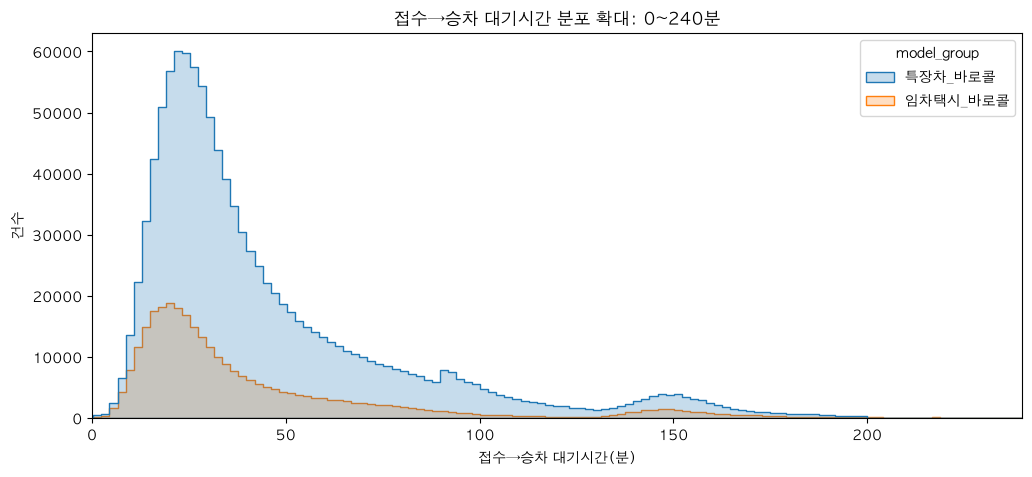

In [8]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=data,
    x="target_min",
    hue="model_group",
    bins=120,
    element="step",
    stat="count",
    common_norm=False,
)

plt.xlim(0, 240)
plt.title("접수→승차 대기시간 분포 확대: 0~240분")
plt.xlabel("접수→승차 대기시간(분)")
plt.ylabel("건수")
plt.show()

120~180분 구간 건수: 114433


,건수,평균,중앙값,p25,p75,최솟값,최댓값
model_group,,,,,,,
임차택시_바로콜,22643,144.33,147.31,137.20,156.96,100.0,180.0
특장차_바로콜,91790,134.84,138.79,112.98,152.60,100.0,180.0


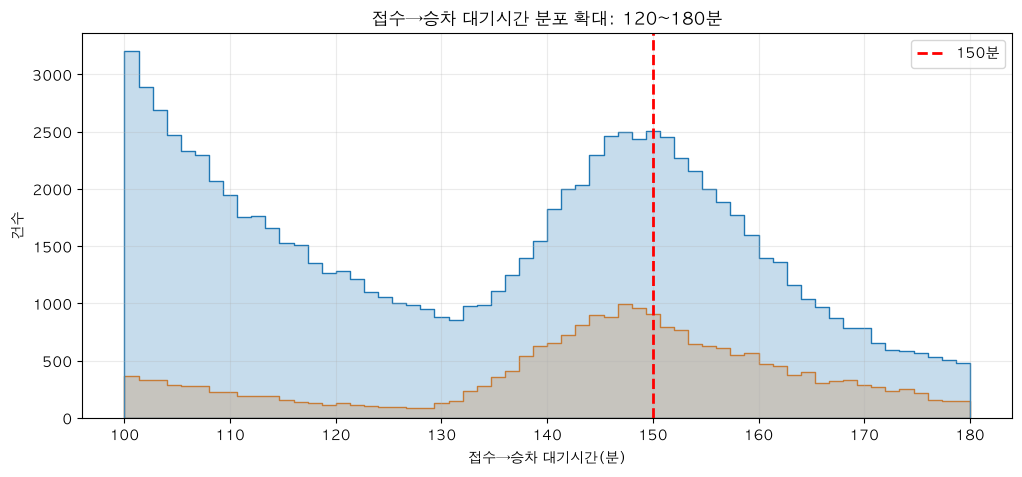

In [9]:
# =========================
# 150분 부근 확대: 120~180분
# =========================

zoom_data = data[
    data["target_min"].between(100, 180, inclusive="both")
].copy()

print("120~180분 구간 건수:", len(zoom_data))

display(
    zoom_data
    .groupby("model_group")["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        최솟값="min",
        최댓값="max",
    )
    .round(2)
)

plt.figure(figsize=(12, 5))

sns.histplot(
    data=zoom_data,
    x="target_min",
    hue="model_group",
    bins=60,
    element="step",
    stat="count",
    common_norm=False,
)

plt.axvline(150, color="red", linestyle="--", linewidth=2, label="150분")
plt.title("접수→승차 대기시간 분포 확대: 120~180분")
plt.xlabel("접수→승차 대기시간(분)")
plt.ylabel("건수")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

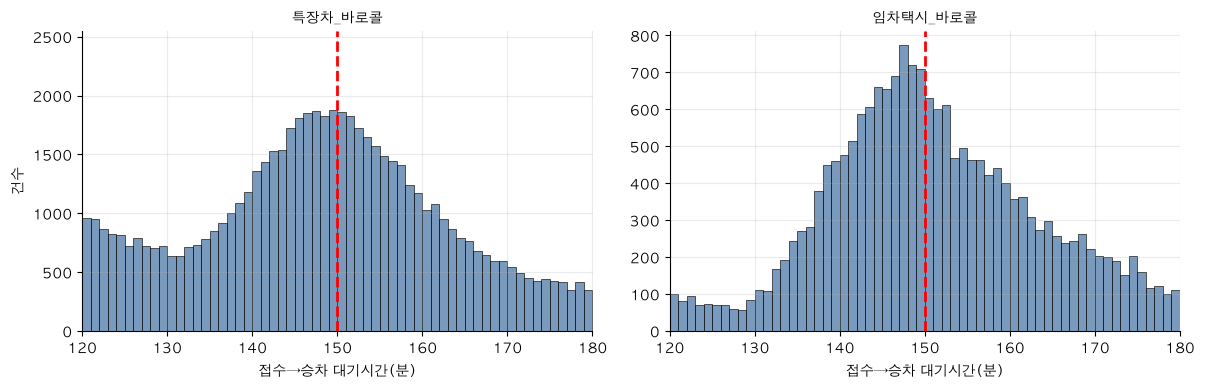

In [10]:
# =========================
# 차량유형별 150분 부근 분포 따로 보기
# =========================

g = sns.FacetGrid(
    zoom_data,
    col="model_group",
    height=4,
    aspect=1.5,
    sharey=False,
)

g.map_dataframe(
    sns.histplot,
    x="target_min",
    binwidth=1,
    color="#4e79a7",
)

for ax in g.axes.flat:
    ax.axvline(150, color="red", linestyle="--", linewidth=2)
    ax.set_xlim(120, 180)
    ax.grid(alpha=0.25)

g.set_axis_labels("접수→승차 대기시간(분)", "건수")
g.set_titles("{col_name}")
plt.show()

## 5. 02~06시 여부별 분포

In [11]:
data_time_compare = data.copy()

data_time_compare["시간구분"] = np.where(
    data_time_compare["hour"].between(2, 6, inclusive="both"),
    "02~06시",
    "그 외 시간",
)

dawn_compare = (
    data_time_compare
    .groupby(["model_group", "시간구분"])["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        최댓값="max",
    )
    .reset_index()
)

display(dawn_compare.round(2))

,model_group,시간구분,건수,평균,중앙값,p75,p90,p95,p99,최댓값
0,임차택시_바로콜,02~06시,16714,121.13,145.91,161.88,180.53,195.03,219.59,246.91
1,임차택시_바로콜,그 외 시간,289015,37.90,27.40,45.69,74.90,99.90,156.26,249.90
2,특장차_바로콜,02~06시,46271,103.50,106.87,155.69,172.75,182.83,194.65,199.99
3,특장차_바로콜,그 외 시간,1052813,43.75,32.62,54.33,89.26,111.66,156.25,199.92


In [12]:
# =========================
# 02~06시 데이터만 추출
# =========================

dawn_data = data[
    data["hour"].between(2, 6, inclusive="both")
].copy()

print("02~06시 데이터 건수:", len(dawn_data))

display(
    dawn_data
    .groupby("model_group")["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        p90=lambda x: x.quantile(0.90),
        최댓값="max",
    )
    .round(2)
)

02~06시 데이터 건수: 62985


,건수,평균,중앙값,p90,최댓값
model_group,,,,,
임차택시_바로콜,16714,121.13,145.91,180.53,246.91
특장차_바로콜,46271,103.50,106.87,172.75,199.99


## 6. 일반구간 모델링 데이터 생성

전체 데이터는 삭제하지 않고 보존한다.

다만 일반적인 대기시간 예측 모델은 아래 구간을 학습 대상에서 제외한 데이터로 만든다.

```text
제외 조건
1. 접수→승차 대기시간이 130분 초과
2. 접수시간대가 02~06시

In [13]:
# =========================
# 6. 일반구간 / 별도관리 데이터 분리
# =========================

long_wait_cutoff = 130

is_long_tail = data["target_min"].gt(long_wait_cutoff)
is_dawn_02_06 = data["hour"].between(2, 6, inclusive="both")

general_mask = ~is_long_tail & ~is_dawn_02_06

general_model_data = data[general_mask].copy()
excluded_model_data = data[~general_mask].copy()

print("전체 데이터:", data.shape)
print("일반구간 모델링 데이터:", general_model_data.shape)
print("별도관리 데이터:", excluded_model_data.shape)
print("별도관리 비율(%):", round(len(excluded_model_data) / len(data) * 100, 2))

전체 데이터: (1404813, 67)
일반구간 모델링 데이터: (1293478, 67)
별도관리 데이터: (111335, 67)
별도관리 비율(%): 7.93


In [14]:
# =========================
# 6-1. 제외 조건별 건수 확인
# =========================

exclude_summary = pd.Series({
    "전체 건수": len(data),
    "130분 초과 건수": is_long_tail.sum(),
    "02~06시 건수": is_dawn_02_06.sum(),
    "130분 초과 & 02~06시 건수": (is_long_tail & is_dawn_02_06).sum(),
    "130분 초과 비율(%)": is_long_tail.mean() * 100,
    "02~06시 비율(%)": is_dawn_02_06.mean() * 100,
    "겹침 비율 - 전체 대비(%)": (is_long_tail & is_dawn_02_06).mean() * 100,
    "별도관리 전체 비율(%)": (~general_mask).mean() * 100,
})

exclude_summary.round(2)

전체 건수                  1404813.00
130분 초과 건수               78429.00
02~06시 건수                62985.00
130분 초과 & 02~06시 건수      30079.00
130분 초과 비율(%)                5.58
02~06시 비율(%)                 4.48
겹침 비율 - 전체 대비(%)             2.14
별도관리 전체 비율(%)                7.93
dtype: float64

In [15]:
# =========================
# 6-2. 차량유형별 일반구간 / 별도관리 구분 확인
# =========================

data_exclude_check = data.copy()

data_exclude_check["모델링구분"] = np.where(
    general_mask,
    "일반구간_모델링",
    "별도관리_제외",
)

data_exclude_check["제외사유"] = np.select(
    [
        is_long_tail & is_dawn_02_06,
        is_long_tail,
        is_dawn_02_06,
    ],
    [
        "130분초과_AND_02~06시",
        "130분초과",
        "02~06시",
    ],
    default="일반구간",
)

exclude_by_group = (
    data_exclude_check
    .groupby(["model_group", "제외사유"])
    .agg(
        건수=("target_min", "size"),
        평균=("target_min", "mean"),
        중앙값=("target_min", "median"),
        p90=("target_min", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

exclude_by_group["전체대비비율(%)"] = exclude_by_group["건수"] / len(data) * 100

display(exclude_by_group.round(2))

,model_group,제외사유,건수,평균,중앙값,p90,전체대비비율(%)
0,임차택시_바로콜,02~06시,6667,58.32,55.86,96.93,0.47
1,임차택시_바로콜,130분초과,10767,151.95,148.25,171.70,0.77
2,임차택시_바로콜,130분초과_AND_02~06시,10047,162.81,158.17,192.16,0.72
3,임차택시_바로콜,일반구간,278248,33.49,26.61,65.97,19.81
4,특장차_바로콜,02~06시,26239,59.67,53.13,110.85,1.87
5,특장차_바로콜,130분초과,37583,151.28,149.14,169.18,2.68
6,특장차_바로콜,130분초과_AND_02~06시,20032,160.92,158.55,184.48,1.43
7,특장차_바로콜,일반구간,1015230,39.77,31.72,78.40,72.27


In [16]:
# =========================
# 6-3. 일반구간 모델링 데이터 분포 확인
# =========================

display(
    general_model_data
    .groupby("model_group")["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        최댓값="max",
    )
    .round(2)
)

,건수,평균,중앙값,p75,p90,p95,최댓값
model_group,,,,,,,
임차택시_바로콜,278248,33.49,26.61,42.41,65.97,79.68,129.98
특장차_바로콜,1015230,39.77,31.72,50.62,78.40,94.12,130.00


## 7. train / validation / test 분리

기존 모델링과 동일하게 데이터를 70% / 15% / 15%로 나눈다.

분리 기준도 기존과 동일하게 `month × model_group`을 stratify 기준으로 사용한다.

이 방식은 월별 분포와 임차택시/특장차 비율이 train / validation / test에 비슷하게 유지되도록 하기 위한 것이다.

이번 모델에서는 일반구간 모델링 데이터인 `general_model_data`를 기준으로 분리한다.

In [17]:
# =========================
# 7. train / validation / test split 함수
# =========================

from sklearn.model_selection import train_test_split

def split_train_valid_test(frame):
    split_key = frame["month"].astype(str) + "_" + frame["model_group"].astype(str)

    train_df, temp_df = train_test_split(
        frame,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=split_key,
    )

    temp_split_key = temp_df["month"].astype(str) + "_" + temp_df["model_group"].astype(str)

    valid_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=temp_split_key,
    )

    train_df = train_df.sort_values("접수일시").reset_index(drop=True)
    valid_df = valid_df.sort_values("접수일시").reset_index(drop=True)
    test_df = test_df.sort_values("접수일시").reset_index(drop=True)

    return train_df, valid_df, test_df

In [18]:
# =========================
# 7-1. 일반구간 데이터 split
# =========================

train, valid, test = split_train_valid_test(general_model_data)

print("train:", train.shape)
print("valid:", valid.shape)
print("test:", test.shape)

train: (905434, 67)
valid: (194022, 67)
test: (194022, 67)


In [19]:
# =========================
# 7-2. split 결과 요약
# =========================

def split_summary(frame, name):
    return {
        "split": name,
        "rows": len(frame),
        "target_mean": frame["target_min"].mean(),
        "target_median": frame["target_min"].median(),
        "target_p90": frame["target_min"].quantile(0.90),
        "target_max": frame["target_min"].max(),
        "min_date": frame["접수일시"].min(),
        "max_date": frame["접수일시"].max(),
    }


split_summary_df = pd.DataFrame([
    split_summary(train, "train"),
    split_summary(valid, "valid"),
    split_summary(test, "test"),
])

display(split_summary_df.round(4))

/var/folders/br/x7f7fw1907z6wpb38fpn1kpm0000gn/T/ipykernel_23241/3316341817.py:24: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(split_summary_df.round(4))


,split,rows,target_mean,target_median,target_p90,target_max,min_date,max_date
0,train,905434,38.4277,30.6120,75.6889,129.9986,2025-01-01 00:01:26.127,2025-12-31 23:31:37.000
1,valid,194022,38.4567,30.6165,75.6732,129.9884,2025-01-01 00:03:40.573,2025-12-31 23:52:59.000
2,test,194022,38.3580,30.5818,75.4802,129.9927,2025-01-01 00:03:31.230,2025-12-31 23:40:56.080


In [20]:
# =========================
# 7-3. model_group 비율 확인
# =========================

model_group_ratio = pd.concat(
    [
        train["model_group"].value_counts(normalize=True).rename("train"),
        valid["model_group"].value_counts(normalize=True).rename("valid"),
        test["model_group"].value_counts(normalize=True).rename("test"),
    ],
    axis=1,
)

display(model_group_ratio.round(4))

,train,valid,test
model_group,,,
특장차_바로콜,0.7849,0.7849,0.7849
임차택시_바로콜,0.2151,0.2151,0.2151


In [21]:
# =========================
# 7-4. month 비율 확인
# =========================

month_ratio = pd.concat(
    [
        train["month"].value_counts(normalize=True).sort_index().rename("train"),
        valid["month"].value_counts(normalize=True).sort_index().rename("valid"),
        test["month"].value_counts(normalize=True).sort_index().rename("test"),
    ],
    axis=1,
)

display(month_ratio.round(4))

,train,valid,test
month,,,
1,0.0745,0.0745,0.0745
2,0.0774,0.0774,0.0774
3,0.0819,0.0819,0.0819
4,0.0852,0.0852,0.0852
5,0.0806,0.0806,0.0806
6,0.0822,0.0822,0.0822
7,0.0945,0.0945,0.0945
8,0.0875,0.0875,0.0875
9,0.0881,0.0881,0.0881


In [22]:
model_group_ratio = pd.concat(
    [
        train["model_group"].value_counts(normalize=True).rename("train"),
        valid["model_group"].value_counts(normalize=True).rename("valid"),
        test["model_group"].value_counts(normalize=True).rename("test"),
    ],
    axis=1,
)

display(model_group_ratio.round(4))

,train,valid,test
model_group,,,
특장차_바로콜,0.7849,0.7849,0.7849
임차택시_바로콜,0.2151,0.2151,0.2151


## 8. Feature Set v2: Ridge 모델링

이번 실험에서는 RF와 동일한 Feature Set v2를 사용하되, 모델만 Ridge Regression으로 변경한다.

사용 피처는 아래 11개다.

```python
FEATURES_V2 = [
    "hour",
    "이용목적",
    "승차거리",
    "출발동",
    "목적동",
    "출발구",
    "목적구",
    "month",
    "세부이동유형",
    "dayofweek",
    "model_group",
]
```

주의:

- `접수_승차_분`, `접수_배차_분`, `배차_승차_분`은 결과 이후에 알 수 있는 값이므로 모델 입력에서 제외한다.
- Ridge는 선형 모델이므로 범주형 변수는 `OneHotEncoder`로 처리한다.
- One-Hot으로 지역·시간·차량유형별 평균 효과를 선형적으로 학습할 수 있는지 확인한다.


In [23]:
# =========================
# 8-1. Feature Set v2 정의
# =========================

FEATURES_V2 = [
    "hour",
    "이용목적",
    "승차거리",
    "출발동",
    "목적동",
    "출발구",
    "목적구",
    "month",
    "세부이동유형",
    "dayofweek",
    "model_group",
]

TARGET_COL = "target_min"

missing_features = [col for col in FEATURES_V2 if col not in train.columns]
if missing_features:
    raise ValueError(f"train에 없는 피처가 있습니다: {missing_features}")

# 승차거리는 모델 입력용 수치형으로 통일
for frame in [train, valid, test]:
    frame["승차거리"] = pd.to_numeric(frame["승차거리"], errors="coerce")

print("FEATURES_V2 개수:", len(FEATURES_V2))
print(FEATURES_V2)

display(train[FEATURES_V2 + [TARGET_COL]].head())

FEATURES_V2 개수: 11
['hour', '이용목적', '승차거리', '출발동', '목적동', '출발구', '목적구', 'month', '세부이동유형', 'dayofweek', 'model_group']


,hour,이용목적,승차거리,출발동,목적동,출발구,목적구,month,세부이동유형,dayofweek,model_group,target_min
0,0,기타,17667,남영동,수유제2동,용산구,강북구,1,구 간 이동,2,특장차_바로콜,48.447333
1,0,기타,4858,상일동,성내제2동,강동구,강동구,1,구 내 이동,2,특장차_바로콜,52.051550
2,0,귀가,5145,중계2.3동,상계1동,노원구,노원구,1,구 내 이동,2,특장차_바로콜,38.206117
3,0,기타,9000,이화동,월계2동,종로구,노원구,1,구 간 이동,2,특장차_바로콜,92.664717
4,0,귀가,9702,여의동,증산동,영등포구,은평구,1,구 간 이동,2,특장차_바로콜,82.073717


## 9. 평가 함수 정의

회귀 성능은 MAE, Median AE, RMSE, R²로 확인한다.

장시간 대기 위험 예측 성능은 train set의 `target_min` 90분위수를 기준으로 Accuracy, Precision, Recall, F1을 확인한다.

In [24]:
# =========================
# 9-1. 평가 함수
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "Median_AE": median_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def risk_metrics(y_true, y_pred, threshold):
    actual = y_true >= threshold
    pred = y_pred >= threshold
    return {
        "threshold": threshold,
        "Accuracy": accuracy_score(actual, pred),
        "Precision": precision_score(actual, pred, zero_division=0),
        "Recall": recall_score(actual, pred, zero_division=0),
        "F1": f1_score(actual, pred, zero_division=0),
        "Confusion_Matrix": confusion_matrix(actual, pred, labels=[False, True]).tolist(),
    }


def evaluate_predictions(frame, pred, threshold):
    y = frame["target_min"].to_numpy()
    return {
        **regression_metrics(y, pred),
        **{f"risk_{k}": v for k, v in risk_metrics(y, pred, threshold).items()},
    }


## 10. Ridge Regression 모델 학습

범주형 변수는 `OneHotEncoder`로 변환하고, 수치형 변수는 `StandardScaler`로 스케일링한다.

`LinearRegression` 대신 `Ridge`를 사용하는 이유는 One-Hot Encoding으로 생성되는 많은 범주형 더미 변수에서 과적합을 줄이고, 계수를 안정화하기 위해서이다.

In [25]:
# =========================
# 10-1. Ridge Pipeline 구성
# =========================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

CATEGORICAL_COLS_V2 = [
    "이용목적",
    "출발동",
    "목적동",
    "출발구",
    "목적구",
    "세부이동유형",
    "model_group",
]

NUMERIC_COLS_V2 = [
    "hour",
    "승차거리",
    "month",
    "dayofweek",
]


def build_ridge_v2_pipeline(params=None):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                ),
                CATEGORICAL_COLS_V2,
            ),
            (
                "num",
                StandardScaler(with_mean=False),
                NUMERIC_COLS_V2,
            ),
        ],
        remainder="drop",
    )

    default_params = {
        "alpha": 10.0,
        "random_state": RANDOM_STATE,
        "solver": "sag",
        "max_iter": 3000,
        "tol": 1e-3,
    }

    if params:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", Ridge(**default_params)),
    ])


In [26]:
# =========================
# 10-2. Ridge 모델 학습 및 평가
# =========================

long_wait_threshold_v2 = train[TARGET_COL].quantile(0.90)
threshold_by_group_v2 = train.groupby("model_group")[TARGET_COL].quantile(0.90).to_dict()

print("장시간 대기 기준 p90:", round(long_wait_threshold_v2, 4))
print("차량유형별 p90:", {k: round(v, 4) for k, v in threshold_by_group_v2.items()})

ridge_v2_model = build_ridge_v2_pipeline()

ridge_v2_model.fit(
    train[FEATURES_V2],
    train[TARGET_COL],
)

valid_pred_ridge_v2 = ridge_v2_model.predict(valid[FEATURES_V2])
test_pred_ridge_v2 = ridge_v2_model.predict(test[FEATURES_V2])

# 대기시간은 음수가 될 수 없으므로 0분 미만 예측값은 0으로 보정
valid_pred_ridge_v2 = np.clip(valid_pred_ridge_v2, 0, None)
test_pred_ridge_v2 = np.clip(test_pred_ridge_v2, 0, None)

valid_metrics_ridge_v2 = evaluate_predictions(
    valid,
    valid_pred_ridge_v2,
    threshold=long_wait_threshold_v2,
)

test_metrics_ridge_v2 = evaluate_predictions(
    test,
    test_pred_ridge_v2,
    threshold=long_wait_threshold_v2,
)

ridge_v2_results = pd.DataFrame([
    {"model": "Ridge Feature Set v2", "split": "valid", **valid_metrics_ridge_v2},
    {"model": "Ridge Feature Set v2", "split": "test", **test_metrics_ridge_v2},
])

display(
    ridge_v2_results
    .drop(columns=["risk_Confusion_Matrix"], errors="ignore")
    .round(4)
)

print("test confusion matrix:")
test_metrics_ridge_v2["risk_Confusion_Matrix"]


장시간 대기 기준 p90: 75.6889
차량유형별 p90: {'임차택시_바로콜': 66.0455, '특장차_바로콜': 78.443}


,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,Ridge Feature Set v2,valid,17.5309,14.2099,22.8510,0.1183,75.6889,0.9018,0.7866,0.0236,0.0458
1,Ridge Feature Set v2,test,17.4883,14.1777,22.7976,0.1181,75.6889,0.9025,0.7747,0.0236,0.0458


test confusion matrix:


[[174659, 132], [18777, 454]]

## 11. 차량유형별 성능 확인

통합 Ridge 모델이 임차택시 바로콜과 특장차 바로콜에서 각각 어떻게 동작하는지 따로 확인한다.

In [27]:
# =========================
# 11-1. 차량유형별 성능 평가
# =========================

def evaluate_by_group(frame, pred, threshold_by_group):
    tmp = frame[["model_group", TARGET_COL]].copy()
    tmp["prediction"] = pred

    rows = []
    for group, group_df in tmp.groupby("model_group"):
        y = group_df[TARGET_COL].to_numpy()
        p = group_df["prediction"].to_numpy()
        threshold = threshold_by_group[group]

        reg = regression_metrics(y, p)
        risk = risk_metrics(y, p, threshold)

        rows.append({
            "model_group": group,
            "rows": len(group_df),
            **reg,
            "risk_threshold": threshold,
            "risk_Accuracy": risk["Accuracy"],
            "risk_Precision": risk["Precision"],
            "risk_Recall": risk["Recall"],
            "risk_F1": risk["F1"],
        })

    return pd.DataFrame(rows)


group_metrics_ridge_v2 = evaluate_by_group(
    test,
    test_pred_ridge_v2,
    threshold_by_group_v2,
)

display(group_metrics_ridge_v2.round(4))


,model_group,rows,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,임차택시_바로콜,41738,15.4766,12.601,20.2779,0.1088,66.0455,0.9054,0.8594,0.0272,0.0528
1,특장차_바로콜,152284,18.0396,14.654,23.4410,0.1069,78.4430,0.9026,0.7528,0.0222,0.0432


## 12. 공급 proxy 실험 A: 당일 차량운행 대수 추가

서울시설공단 장애인콜택시 일별이용현황 데이터의 `차량운행` 컬럼을 공급 proxy로 추가한다.

실험 A에서는 `접수일자 = 기준일` 기준으로 당일 차량운행 대수를 붙인다.

```python
vehicle_operation_count_today
```

주의:

- `차량운행`은 실시간 배차 가능 차량 수가 아니라 일별 전체 운행 차량 수이다.
- 당일 최종 운행대수는 예측 시점에 확정되지 않았을 수 있으므로, 성능 확인용 실험으로 해석한다.

In [28]:
# =========================
# 12-1. 일별이용현황 데이터 로드
# =========================

DAILY_USAGE_FILENAME = "서울시설공단_장애인콜택시 일별이용현황_20251231.csv"
DAILY_USAGE_PATH = find_csv_in_processed(DATA_DIR, DAILY_USAGE_FILENAME)

print("DAILY_USAGE_PATH:", DAILY_USAGE_PATH)

daily_usage = pd.read_csv(DAILY_USAGE_PATH, low_memory=False)

required_daily_cols = ["기준일", "차량운행"]
missing_daily_cols = [col for col in required_daily_cols if col not in daily_usage.columns]
if missing_daily_cols:
    raise ValueError(f"일별이용현황 데이터에 필요한 컬럼이 없습니다: {missing_daily_cols}")

daily_usage["기준일"] = pd.to_datetime(daily_usage["기준일"], errors="coerce").dt.normalize()
daily_usage["차량운행"] = pd.to_numeric(daily_usage["차량운행"], errors="coerce")

vehicle_operation_today_table = (
    daily_usage
    .dropna(subset=["기준일"])
    .groupby("기준일", as_index=False)
    .agg(vehicle_operation_count_today=("차량운행", "first"))
)

print("일별 차량운행 table shape:", vehicle_operation_today_table.shape)
print("기준일 범위:", vehicle_operation_today_table["기준일"].min(), "~", vehicle_operation_today_table["기준일"].max())

display(vehicle_operation_today_table.head())
display(vehicle_operation_today_table["vehicle_operation_count_today"].describe().to_frame().round(2))


DAILY_USAGE_PATH: /Users/blaumonde/calltaxi-DA/data/processed/서울시설공단_장애인콜택시 일별이용현황_20251231.csv
일별 차량운행 table shape: (365, 2)
기준일 범위: 2025-01-01 00:00:00 ~ 2025-12-31 00:00:00


,기준일,vehicle_operation_count_today
0,2025-01-01,257
1,2025-01-02,665
2,2025-01-03,655
3,2025-01-04,407
4,2025-01-05,242


,vehicle_operation_count_today
count,365.00
mean,594.46
std,213.29
min,207.00
25%,340.00
50%,680.00
75%,772.00
max,853.00


In [29]:
# =========================
# 12-2. train / valid / test에 당일 차량운행 merge
# =========================

TODAY_VEHICLE_OPERATION_COL = "vehicle_operation_count_today"


def add_today_vehicle_operation_count(train_df, valid_df, test_df, daily_table):
    result_frames = []

    train_dates = train_df["접수일시"].dt.normalize()
    train_daily_values = train_dates.to_frame(name="기준일").merge(
        daily_table,
        on="기준일",
        how="left",
    )[TODAY_VEHICLE_OPERATION_COL]
    fallback_value = train_daily_values.median()

    for name, frame in [
        ("train", train_df),
        ("valid", valid_df),
        ("test", test_df),
    ]:
        tmp = frame.copy()
        tmp["_merge_기준일"] = tmp["접수일시"].dt.normalize()

        tmp = tmp.merge(
            daily_table,
            left_on="_merge_기준일",
            right_on="기준일",
            how="left",
        )

        missing_count = tmp[TODAY_VEHICLE_OPERATION_COL].isna().sum()
        tmp[TODAY_VEHICLE_OPERATION_COL] = tmp[TODAY_VEHICLE_OPERATION_COL].fillna(fallback_value)
        tmp = tmp.drop(columns=["_merge_기준일", "기준일"], errors="ignore")

        print(f"{name}: shape={tmp.shape}, {TODAY_VEHICLE_OPERATION_COL} 결측 보완 전={missing_count}")
        result_frames.append(tmp)

    return result_frames


train_supply_today, valid_supply_today, test_supply_today = add_today_vehicle_operation_count(
    train,
    valid,
    test,
    vehicle_operation_today_table,
)

display(
    train_supply_today[["접수일시", "model_group", TODAY_VEHICLE_OPERATION_COL, TARGET_COL]]
    .head()
)


train: shape=(905434, 68), vehicle_operation_count_today 결측 보완 전=0
valid: shape=(194022, 68), vehicle_operation_count_today 결측 보완 전=0
test: shape=(194022, 68), vehicle_operation_count_today 결측 보완 전=0


,접수일시,model_group,vehicle_operation_count_today,target_min
0,2025-01-01 00:01:26.127,특장차_바로콜,257,48.447333
1,2025-01-01 00:07:46.960,특장차_바로콜,257,52.051550
2,2025-01-01 00:28:16.000,특장차_바로콜,257,38.206117
3,2025-01-01 00:28:20.117,특장차_바로콜,257,92.664717
4,2025-01-01 00:30:31.000,특장차_바로콜,257,82.073717


## 13. Ridge + 당일 차량운행 proxy 재학습

기존 Feature Set v2에 `vehicle_operation_count_today`를 추가해 Ridge 모델을 다시 학습한다.

In [30]:
# =========================
# 13-1. 당일 차량운행 추가 Feature Set / Pipeline
# =========================

FEATURES_V2_SUPPLY_TODAY = FEATURES_V2 + [
    TODAY_VEHICLE_OPERATION_COL,
]

NUMERIC_COLS_V2_SUPPLY_TODAY = NUMERIC_COLS_V2 + [
    TODAY_VEHICLE_OPERATION_COL,
]


def build_ridge_v2_supply_today_pipeline(params=None):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                ),
                CATEGORICAL_COLS_V2,
            ),
            (
                "num",
                StandardScaler(with_mean=False),
                NUMERIC_COLS_V2_SUPPLY_TODAY,
            ),
        ],
        remainder="drop",
    )

    default_params = {
        "alpha": 10.0,
        "random_state": RANDOM_STATE,
        "solver": "sag",
        "max_iter": 3000,
        "tol": 1e-3,
    }

    if params:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", Ridge(**default_params)),
    ])


print("당일 차량운행 추가 후 피처 수:", len(FEATURES_V2_SUPPLY_TODAY))
print(FEATURES_V2_SUPPLY_TODAY)


당일 차량운행 추가 후 피처 수: 12
['hour', '이용목적', '승차거리', '출발동', '목적동', '출발구', '목적구', 'month', '세부이동유형', 'dayofweek', 'model_group', 'vehicle_operation_count_today']


In [31]:
# =========================
# 13-2. Ridge + 당일 차량운행 proxy 학습 및 평가
# =========================

ridge_v2_supply_today_model = build_ridge_v2_supply_today_pipeline()

ridge_v2_supply_today_model.fit(
    train_supply_today[FEATURES_V2_SUPPLY_TODAY],
    train_supply_today[TARGET_COL],
)

valid_pred_ridge_v2_supply_today = ridge_v2_supply_today_model.predict(valid_supply_today[FEATURES_V2_SUPPLY_TODAY])
test_pred_ridge_v2_supply_today = ridge_v2_supply_today_model.predict(test_supply_today[FEATURES_V2_SUPPLY_TODAY])

valid_pred_ridge_v2_supply_today = np.clip(valid_pred_ridge_v2_supply_today, 0, None)
test_pred_ridge_v2_supply_today = np.clip(test_pred_ridge_v2_supply_today, 0, None)

valid_metrics_ridge_v2_supply_today = evaluate_predictions(
    valid_supply_today,
    valid_pred_ridge_v2_supply_today,
    threshold=long_wait_threshold_v2,
)

test_metrics_ridge_v2_supply_today = evaluate_predictions(
    test_supply_today,
    test_pred_ridge_v2_supply_today,
    threshold=long_wait_threshold_v2,
)

ridge_v2_supply_today_results = pd.DataFrame([
    {"model": "Ridge Feature Set v2 + vehicle_operation_count_today", "split": "valid", **valid_metrics_ridge_v2_supply_today},
    {"model": "Ridge Feature Set v2 + vehicle_operation_count_today", "split": "test", **test_metrics_ridge_v2_supply_today},
])

display(
    ridge_v2_supply_today_results
    .drop(columns=["risk_Confusion_Matrix"], errors="ignore")
    .round(4)
)

print("test confusion matrix:")
test_metrics_ridge_v2_supply_today["risk_Confusion_Matrix"]


,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,Ridge Feature Set v2 + vehicle_operation_count...,valid,17.5271,14.2012,22.8476,0.1186,75.6889,0.9018,0.7852,0.0236,0.0458
1,Ridge Feature Set v2 + vehicle_operation_count...,test,17.4840,14.1690,22.7937,0.1184,75.6889,0.9025,0.7747,0.0236,0.0458


test confusion matrix:


[[174659, 132], [18777, 454]]

## 14. 공급 proxy 실험 B: 전일 차량운행 대수 추가

실험 B에서는 예측 시점 이전에 이미 확인 가능한 값인 전일 차량운행 대수를 공급 proxy로 사용한다.

```python
vehicle_operation_count_prev_day
```

이 피처는 당일 최종 운행대수보다 실서비스 적용 관점에서 leakage 위험이 낮다.

In [32]:
# =========================
# 14-1. 전일 차량운행 table 생성 및 merge
# =========================

PREV_DAY_VEHICLE_OPERATION_COL = "vehicle_operation_count_prev_day"

vehicle_operation_prev_day_table = vehicle_operation_today_table.copy()
vehicle_operation_prev_day_table["기준일"] = vehicle_operation_prev_day_table["기준일"] + pd.Timedelta(days=1)
vehicle_operation_prev_day_table = vehicle_operation_prev_day_table.rename(
    columns={"vehicle_operation_count_today": PREV_DAY_VEHICLE_OPERATION_COL}
)


def add_prev_day_vehicle_operation_count(train_df, valid_df, test_df, prev_day_table):
    result_frames = []

    train_dates = train_df["접수일시"].dt.normalize()
    train_daily_values = train_dates.to_frame(name="기준일").merge(
        prev_day_table,
        on="기준일",
        how="left",
    )[PREV_DAY_VEHICLE_OPERATION_COL]
    fallback_value = train_daily_values.median()

    for name, frame in [
        ("train", train_df),
        ("valid", valid_df),
        ("test", test_df),
    ]:
        tmp = frame.copy()
        tmp["_merge_기준일"] = tmp["접수일시"].dt.normalize()

        tmp = tmp.merge(
            prev_day_table,
            left_on="_merge_기준일",
            right_on="기준일",
            how="left",
        )

        missing_count = tmp[PREV_DAY_VEHICLE_OPERATION_COL].isna().sum()
        tmp[PREV_DAY_VEHICLE_OPERATION_COL] = tmp[PREV_DAY_VEHICLE_OPERATION_COL].fillna(fallback_value)
        tmp = tmp.drop(columns=["_merge_기준일", "기준일"], errors="ignore")

        print(f"{name}: shape={tmp.shape}, {PREV_DAY_VEHICLE_OPERATION_COL} 결측 보완 전={missing_count}")
        result_frames.append(tmp)

    return result_frames


train_supply_prev_day, valid_supply_prev_day, test_supply_prev_day = add_prev_day_vehicle_operation_count(
    train,
    valid,
    test,
    vehicle_operation_prev_day_table,
)

display(
    train_supply_prev_day[["접수일시", "model_group", PREV_DAY_VEHICLE_OPERATION_COL, TARGET_COL]]
    .head()
)


train: shape=(905434, 68), vehicle_operation_count_prev_day 결측 보완 전=768
valid: shape=(194022, 68), vehicle_operation_count_prev_day 결측 보완 전=145
test: shape=(194022, 68), vehicle_operation_count_prev_day 결측 보완 전=147


,접수일시,model_group,vehicle_operation_count_prev_day,target_min
0,2025-01-01 00:01:26.127,특장차_바로콜,723.0,48.447333
1,2025-01-01 00:07:46.960,특장차_바로콜,723.0,52.051550
2,2025-01-01 00:28:16.000,특장차_바로콜,723.0,38.206117
3,2025-01-01 00:28:20.117,특장차_바로콜,723.0,92.664717
4,2025-01-01 00:30:31.000,특장차_바로콜,723.0,82.073717


## 15. Ridge + 전일 차량운행 proxy 재학습

기존 Feature Set v2에 `vehicle_operation_count_prev_day`를 추가해 Ridge 모델을 다시 학습한다.

In [33]:
# =========================
# 15-1. 전일 차량운행 추가 Feature Set / Pipeline
# =========================

FEATURES_V2_SUPPLY_PREV_DAY = FEATURES_V2 + [
    PREV_DAY_VEHICLE_OPERATION_COL,
]

NUMERIC_COLS_V2_SUPPLY_PREV_DAY = NUMERIC_COLS_V2 + [
    PREV_DAY_VEHICLE_OPERATION_COL,
]


def build_ridge_v2_supply_prev_day_pipeline(params=None):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                ),
                CATEGORICAL_COLS_V2,
            ),
            (
                "num",
                StandardScaler(with_mean=False),
                NUMERIC_COLS_V2_SUPPLY_PREV_DAY,
            ),
        ],
        remainder="drop",
    )

    default_params = {
        "alpha": 10.0,
        "random_state": RANDOM_STATE,
        "solver": "sag",
        "max_iter": 3000,
        "tol": 1e-3,
    }

    if params:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", Ridge(**default_params)),
    ])


print("전일 차량운행 추가 후 피처 수:", len(FEATURES_V2_SUPPLY_PREV_DAY))
print(FEATURES_V2_SUPPLY_PREV_DAY)


전일 차량운행 추가 후 피처 수: 12
['hour', '이용목적', '승차거리', '출발동', '목적동', '출발구', '목적구', 'month', '세부이동유형', 'dayofweek', 'model_group', 'vehicle_operation_count_prev_day']


In [34]:
# =========================
# 15-2. Ridge + 전일 차량운행 proxy 학습 및 평가
# =========================

ridge_v2_supply_prev_day_model = build_ridge_v2_supply_prev_day_pipeline()

ridge_v2_supply_prev_day_model.fit(
    train_supply_prev_day[FEATURES_V2_SUPPLY_PREV_DAY],
    train_supply_prev_day[TARGET_COL],
)

valid_pred_ridge_v2_supply_prev_day = ridge_v2_supply_prev_day_model.predict(valid_supply_prev_day[FEATURES_V2_SUPPLY_PREV_DAY])
test_pred_ridge_v2_supply_prev_day = ridge_v2_supply_prev_day_model.predict(test_supply_prev_day[FEATURES_V2_SUPPLY_PREV_DAY])

valid_pred_ridge_v2_supply_prev_day = np.clip(valid_pred_ridge_v2_supply_prev_day, 0, None)
test_pred_ridge_v2_supply_prev_day = np.clip(test_pred_ridge_v2_supply_prev_day, 0, None)

valid_metrics_ridge_v2_supply_prev_day = evaluate_predictions(
    valid_supply_prev_day,
    valid_pred_ridge_v2_supply_prev_day,
    threshold=long_wait_threshold_v2,
)

test_metrics_ridge_v2_supply_prev_day = evaluate_predictions(
    test_supply_prev_day,
    test_pred_ridge_v2_supply_prev_day,
    threshold=long_wait_threshold_v2,
)

ridge_v2_supply_prev_day_results = pd.DataFrame([
    {"model": "Ridge Feature Set v2 + vehicle_operation_count_prev_day", "split": "valid", **valid_metrics_ridge_v2_supply_prev_day},
    {"model": "Ridge Feature Set v2 + vehicle_operation_count_prev_day", "split": "test", **test_metrics_ridge_v2_supply_prev_day},
])

display(
    ridge_v2_supply_prev_day_results
    .drop(columns=["risk_Confusion_Matrix"], errors="ignore")
    .round(4)
)

print("test confusion matrix:")
test_metrics_ridge_v2_supply_prev_day["risk_Confusion_Matrix"]


,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,Ridge Feature Set v2 + vehicle_operation_count...,valid,17.5273,14.2126,22.8473,0.1186,75.6889,0.9018,0.7862,0.0235,0.0457
1,Ridge Feature Set v2 + vehicle_operation_count...,test,17.4846,14.1824,22.7942,0.1183,75.6889,0.9025,0.7734,0.0236,0.0458


test confusion matrix:


[[174658, 133], [18777, 454]]

## 16. Ridge 모델 성능 비교

Ridge 기본 모델, 당일 차량운행 추가 모델, 전일 차량운행 추가 모델을 비교한다.

- `MAE`를 최우선으로 확인한다.
- 당일 차량운행은 성능 확인용이다.
- 전일 차량운행은 실서비스 적용 가능성이 더 높은 공급 proxy이다.

In [35]:
# =========================
# 16-1. Ridge baseline vs 차량운행 proxy 비교
# =========================

ridge_supply_compare = pd.concat(
    [
        ridge_v2_results.assign(feature_set="Feature Set v2"),
        ridge_v2_supply_today_results.assign(feature_set="Feature Set v2 + vehicle_operation_count_today"),
        ridge_v2_supply_prev_day_results.assign(feature_set="Feature Set v2 + vehicle_operation_count_prev_day"),
    ],
    ignore_index=True,
)

compare_cols = [
    "feature_set",
    "model",
    "split",
    "MAE",
    "Median_AE",
    "RMSE",
    "R2",
    "risk_threshold",
    "risk_Accuracy",
    "risk_Precision",
    "risk_Recall",
    "risk_F1",
]

display(
    ridge_supply_compare[compare_cols]
    .sort_values(["split", "MAE"])
    .round(4)
)

baseline_test = ridge_v2_results.query("split == 'test'").iloc[0]
today_test = ridge_v2_supply_today_results.query("split == 'test'").iloc[0]
prev_day_test = ridge_v2_supply_prev_day_results.query("split == 'test'").iloc[0]

summary_rows = []
for feature_set, row in [
    ("vehicle_operation_count_today", today_test),
    ("vehicle_operation_count_prev_day", prev_day_test),
]:
    for metric in ["MAE", "Median_AE", "RMSE", "risk_F1"]:
        summary_rows.append({
            "feature_set": feature_set,
            "metric": metric,
            "baseline": baseline_test[metric],
            "proxy_model": row[metric],
            "diff_proxy_minus_baseline": row[metric] - baseline_test[metric],
        })

ridge_supply_improvement_summary = pd.DataFrame(summary_rows)

display(ridge_supply_improvement_summary.round(4))


,feature_set,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
3,Feature Set v2 + vehicle_operation_count_today,Ridge Feature Set v2 + vehicle_operation_count...,test,17.4840,14.1690,22.7937,0.1184,75.6889,0.9025,0.7747,0.0236,0.0458
5,Feature Set v2 + vehicle_operation_count_prev_day,Ridge Feature Set v2 + vehicle_operation_count...,test,17.4846,14.1824,22.7942,0.1183,75.6889,0.9025,0.7734,0.0236,0.0458
1,Feature Set v2,Ridge Feature Set v2,test,17.4883,14.1777,22.7976,0.1181,75.6889,0.9025,0.7747,0.0236,0.0458
2,Feature Set v2 + vehicle_operation_count_today,Ridge Feature Set v2 + vehicle_operation_count...,valid,17.5271,14.2012,22.8476,0.1186,75.6889,0.9018,0.7852,0.0236,0.0458
4,Feature Set v2 + vehicle_operation_count_prev_day,Ridge Feature Set v2 + vehicle_operation_count...,valid,17.5273,14.2126,22.8473,0.1186,75.6889,0.9018,0.7862,0.0235,0.0457
0,Feature Set v2,Ridge Feature Set v2,valid,17.5309,14.2099,22.8510,0.1183,75.6889,0.9018,0.7866,0.0236,0.0458


,feature_set,metric,baseline,proxy_model,diff_proxy_minus_baseline
0,vehicle_operation_count_today,MAE,17.4883,17.4840,-0.0043
1,vehicle_operation_count_today,Median_AE,14.1777,14.1690,-0.0087
2,vehicle_operation_count_today,RMSE,22.7976,22.7937,-0.0039
3,vehicle_operation_count_today,risk_F1,0.0458,0.0458,0.0000
4,vehicle_operation_count_prev_day,MAE,17.4883,17.4846,-0.0036
5,vehicle_operation_count_prev_day,Median_AE,14.1777,14.1824,0.0047
6,vehicle_operation_count_prev_day,RMSE,22.7976,22.7942,-0.0034
7,vehicle_operation_count_prev_day,risk_F1,0.0458,0.0458,-0.0000


In [36]:
# =========================
# 16-2. Ridge + 전일 차량운행 모델 차량유형별 성능 평가
# =========================

group_metrics_ridge_v2_supply_prev_day = evaluate_by_group(
    test_supply_prev_day,
    test_pred_ridge_v2_supply_prev_day,
    threshold_by_group_v2,
)

display(group_metrics_ridge_v2_supply_prev_day.round(4))


,model_group,rows,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,임차택시_바로콜,41738,15.4732,12.5931,20.2771,0.1089,66.0455,0.9054,0.8661,0.0272,0.0528
1,특장차_바로콜,152284,18.0359,14.6591,23.4370,0.1072,78.4430,0.9026,0.7517,0.0221,0.0430


## 17. 해석 메모

Ridge Regression은 트리 기반 모델과 달리 지역, 시간대, 차량유형, 이동유형의 효과를 선형적으로 더해 대기시간을 예측한다.

만약 Ridge가 RF와 비슷한 성능을 보이면, 대기시간이 복잡한 비선형 구조보다 지역·시간대별 평균 패턴으로 상당 부분 설명된다는 의미로 해석할 수 있다.

반대로 Ridge가 RF보다 낮은 성능을 보이면, 지역·시간·거리·이동유형 간 비선형 상호작용이 중요하다는 근거로 해석할 수 있다.